#**CoderHouse Data Science III: NLP & Deep Learning**
#Proyecto Final - Comision 77865

##Alumno: Aguero Garcia Josias


---

# La Ejecucion de todo el codigo es de 2hs aprox.

# 📑 Carga directa de datos procesados (lematización + POS tagging)

> **Nota importante:**
>
> Este notebook descarga automáticamente el archivo de datos procesados desde Google Drive usando `gdown`.
>
> **¿Por qué?**  
> - El proceso completo de lematización y POS tagging sobre los 250.000 tweets tarda unos **20 minutos cada uno** (40 minutos en total).
> - Para ahorrar tiempo y recursos, ya incluimos el archivo `tweets_lemmatized_pos.csv` con las columnas `lemmas` (lemas de cada tweet) y `pos` (etiquetas de parte de la oración).
>
> **¿Qué debe hacer?**
> 1. Ejecutar las dos primeras celdas.
> 2. ¡Listo! El DataFrame se cargará en segundos con todas las columnas listas para analizar o entrenar modelos.
>
> Si por algún motivo quiere rehacer el procesamiento desde cero, puede ejecutar las celdas avanzadas al final (demoran ~40 minutos).

# 1 - Instalar & importar librerías

In [ ]:
!pip install -q gdown
!pip install --quiet langdetect nltk
!pip install -q spacy
!python -m spacy download es_core_news_sm


import gdown
import pandas as pd
import nltk, unicodedata, string, re, textwrap, matplotlib.pyplot as plt
import numpy as np
import langdetect, matplotlib
import seaborn as sns
import os
import spacy
import ast
import unicodedata
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from collections import Counter
from statistics import mean, median
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.tokenize import wordpunct_tokenize
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Dropout
from sklearn.model_selection import KFold
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from keras.utils import to_categorical
from keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

matplotlib.rcParams["figure.dpi"] = 120   # gráficos nítidos

#  • «stopwords» → lista de palabras muy comunes (el, la, y…)
nltk.download("stopwords")      # stop-words

# Definir la paleta de colores okabe_lto para gráficos amigables para daltónicos
okabe_lto = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
sns.set_palette(okabe_lto)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 100.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2 - Cargar corpus

In [ ]:
# ID del archivo de Google Drive
file_id = '1ywHJ9ptH-Vr-5QEg3KdEEL6HpZmRBRJT'

# Descarga el archivo
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'tweets_lemmatized_pos.csv', quiet=False)

# Lee el archivo descargado
df = pd.read_csv('tweets_lemmatized_pos.csv')
df['lemmas'] = df['lemmas'].apply(ast.literal_eval)
df['pos'] = df['pos'].apply(ast.literal_eval)

Downloading...
From (original): https://drive.google.com/uc?id=1ywHJ9ptH-Vr-5QEg3KdEEL6HpZmRBRJT
From (redirected): https://drive.google.com/uc?id=1ywHJ9ptH-Vr-5QEg3KdEEL6HpZmRBRJT&confirm=t&uuid=8df97f2d-25b0-4cf0-a4cc-cccca8340dc8
To: /content/tweets_lemmatized_pos.csv
100%|██████████| 205M/205M [00:03<00:00, 62.9MB/s]


# 3 - NLP - EDA inicial

In [ ]:
# Combina todo el texto de tu DataFrame en una sola cadena
raw_text = df['tweet'].dropna().astype(str).str.cat(sep=' ')

# Recuento de oraciones y longitud de cada una
sentences = re.split(r"[.!?]\s+", raw_text)
lengths   = [len(s.split()) for s in sentences if s]

print("Oraciones:", len(sentences))
print("Media:", f"{mean(lengths):.1f}", "| Mediana:", median(lengths))

Oraciones: 463474
Media: 16.4 | Mediana: 12.0


In [ ]:
# Detectar idioma (solo sobre los primeros 3 000 caracteres)
try:
    idioma = langdetect.detect(raw_text[:3000])
except langdetect.lang_detect_exception.LangDetectException:
    idioma = "desconocido"
print("Idioma:", idioma.upper())

# Verificar encoding UTF-8
try:
    raw_text.encode("utf-8")
    print("Encoding UTF-8 válido")
except UnicodeEncodeError:
    print("⚠️  Problema de encoding")

Idioma: ES
Encoding UTF-8 válido


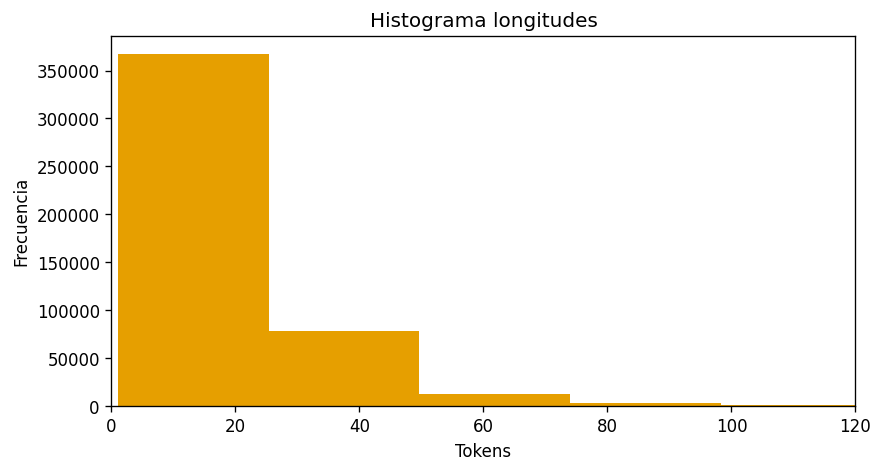

In [ ]:
# Histograma de longitudes
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30)
plt.xlim(0, 120)
plt.title("Histograma longitudes")
plt.xlabel("Tokens")
plt.ylabel("Frecuencia")
plt.show()

Media tokens por tweet: 30.8
Mediana tokens por tweet: 35.0


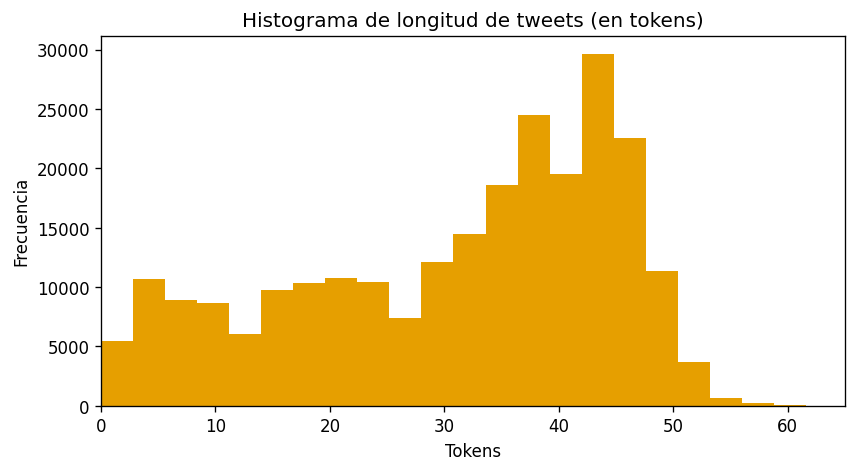

In [ ]:
# Calcula la longitud de cada tweet en tokens
tweet_lengths = df['tweet'].dropna().astype(str).str.split().map(len)

# Estadísticas básicas
print("Media tokens por tweet:", f"{tweet_lengths.mean():.1f}")
print("Mediana tokens por tweet:", tweet_lengths.median())

# Histograma de longitudes de tweets
plt.figure(figsize=(8,4))
plt.hist(tweet_lengths, bins=30)
plt.xlim(0, 65)
plt.title("Histograma de longitud de tweets (en tokens)")
plt.xlabel("Tokens")
plt.ylabel("Frecuencia")
plt.show()

Media caracteres por tweet: 211.3
Mediana caracteres por tweet: 243.0


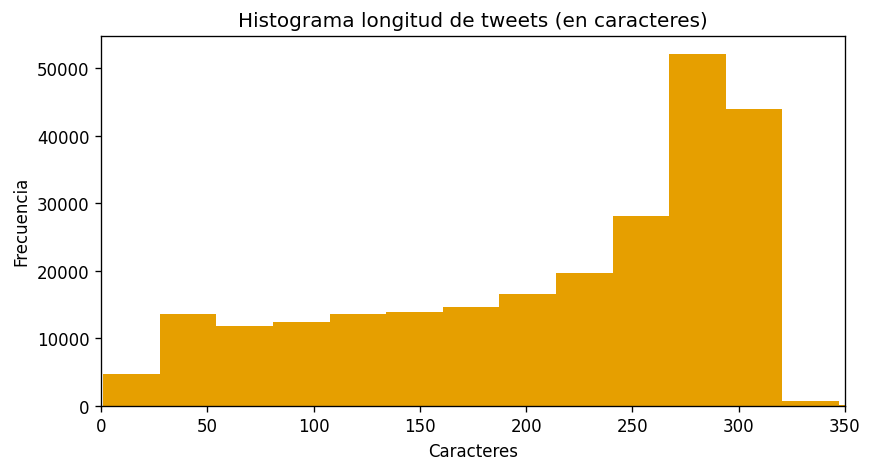

In [ ]:
# Longitud en caracteres de cada tweet
char_lengths = df['tweet'].dropna().astype(str).str.len()

# Estadísticas básicas
print("Media caracteres por tweet:", f"{char_lengths.mean():.1f}")
print("Mediana caracteres por tweet:", char_lengths.median())

# Histograma de longitud en caracteres
plt.figure(figsize=(8,4))
plt.hist(char_lengths, bins=30)
plt.xlim(0, 350)     # ajusta según necesites
plt.title("Histograma longitud de tweets (en caracteres)")
plt.xlabel("Caracteres")
plt.ylabel("Frecuencia")
plt.show()

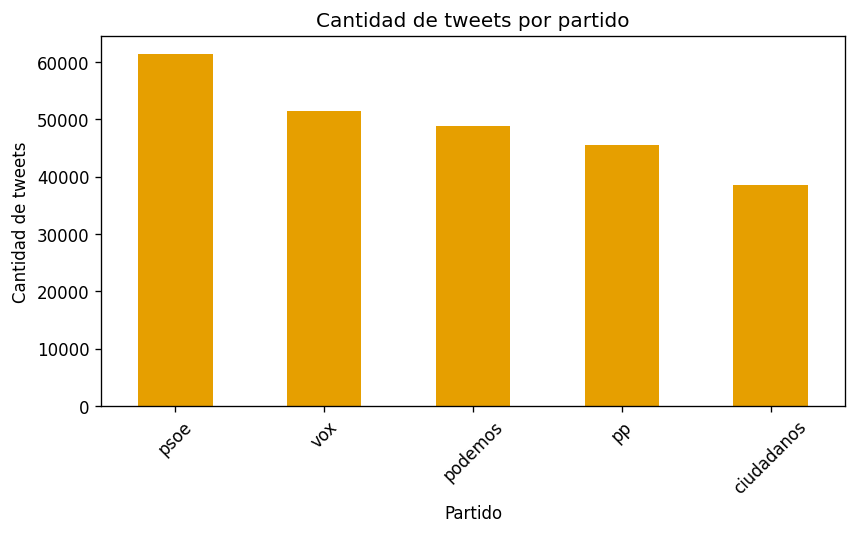

In [ ]:
# Conteo de tweets por partido
counts = df['partido'].value_counts()

plt.figure(figsize=(8,4))
counts.plot(kind='bar')
plt.title("Cantidad de tweets por partido")
plt.xlabel("Partido")
plt.ylabel("Cantidad de tweets")
plt.xticks(rotation=45)
plt.show()

# 4 - Pre-procesamiento

In [ ]:
STOP_ES = set(stopwords.words("spanish"))
PUNCT   = set(string.punctuation)

## Tokenizacion - Stopwords

In [ ]:
def clean_text(text: str) -> list[str]:

    text = unicodedata.normalize("NFKC", text).lower()
    tokens = wordpunct_tokenize(text)
    return [t for t in tokens if t.isalpha() and t not in PUNCT and t not in STOP_ES]

# Aplica al DataFrame
df['tokens'] = df['tweet'].astype(str).apply(clean_text)

### Ejecutar limpieza + medir

In [ ]:
%%time
tokens = clean_text(raw_text)
print("Tokens limpios:", f"{len(tokens):,}")

Tokens limpios: 4,449,945
CPU times: user 7.83 s, sys: 922 ms, total: 8.75 s
Wall time: 8.85 s


### Visualización rápida

In [ ]:
# Top-10 palabras
top10 = Counter(tokens).most_common(10)
print("Top-10 palabras frecuentes:")
for w, f in top10:
    print(f"{w:<15} {f}")

Top-10 palabras frecuentes:
t               212986
co              212874
https           209814
gobierno        31253
españa          27498
hoy             22263
sánchez         16244
gracias         14626
si              13809
pp              13064


## Lematizacion - Pos Tagging

In [ ]:
print("Archivo cargado correctamente desde Google Drive (por enlace gdown).")
df[['tweet', 'lemmas', 'pos']].head()

Archivo cargado correctamente desde Google Drive (por enlace gdown).


,tweet,lemmas,pos
0,@vesteve3 @manubenas @ccoo_rm @desobediencia_ ...,"[ánimo, primavera, iniceír]","[ADJ, NOUN, ADP, DET, NOUN, PRON, VERB]"
1,"@kirovast: @Hugo_Moran muy fan de la ""radical...","[fan, radicalidad, frente, devaluación, democr...","[ADV, ADJ, ADP, DET, NOUN, PROPN, ADP, DET, NO..."
2,@ALTAS_PRESIONES Nuevos dueños para las renova...,"[dueño, renovabl, momento, problema, apuesta, ...","[ADJ, NOUN, ADP, DET, NOUN, ADP, DET, NOUN, AD..."
3,@jumanjisolar @solartradex @josea_dolera El di...,"[diferencial, precio, energético, alemania, fr...","[DET, NOUN, ADP, NOUN, ADJ, ADP, PROPN, CCONJ,..."
4,@cesarnayu: https://t.co/J4OTXj1x7w Por fav...,"[favor, importante, difundir, mensaje, concien...","[ADP, NOUN, AUX, ADJ, VERB, DET, NOUN, ADP, VE..."


# 5 - Deep Learning - Procesamiento de Datos

In [ ]:
# Convierte las listas de lemas en strings para la Tokenizer
df['lemmas_str'] = df['lemmas'].apply(lambda x: ' '.join(x))

# Prepara el Tokenizer
max_words = 10000  # máximo tamaño de vocabulario
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['lemmas_str'])

In [ ]:
# Convierte a secuencias de enteros
sequences = tokenizer.texts_to_sequences(df['lemmas_str'])

# Padding para igualar longitud
maxlen = 30  # tweets son cortos, podés ajustar según análisis
X = pad_sequences(sequences, maxlen=maxlen, padding='post')

## Preparacion del target (y)

In [ ]:
# Codificá la columna 'partido'
le = LabelEncoder()
y = le.fit_transform(df['partido'])
num_classes = len(le.classes_)

# Convierte a one-hot encoding para clasificación multiclase
y_cat = to_categorical(y, num_classes=num_classes)

## Train y Test

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# 6 - Modelado y Entrenamiento Modelo LSTM simple

In [ ]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),
    LSTM(64),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=128
)

Epoch 1/5
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.4757 - loss: 1.2458 - val_accuracy: 0.6275 - val_loss: 0.9537
Epoch 2/5
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 88s 57ms/step - accuracy: 0.6540 - loss: 0.8878 - val_accuracy: 0.6380 - val_loss: 0.9174
Epoch 3/5
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 138s 55ms/step - accuracy: 0.6793 - loss: 0.8184 - val_accuracy: 0.6402 - val_loss: 0.9010
Epoch 4/5
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 141s 54ms/step - accuracy: 0.6931 - loss: 0.7798 - val_accuracy: 0.6445 - val_loss: 0.9107
Epoch 5/5
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.7061 - loss: 0.7410 - val_accuracy: 0.6440 - val_loss: 0.9272


## Evaluacion y Comparacion

1537/1537 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6424 - loss: 0.9304
Accuracy en test: 0.644


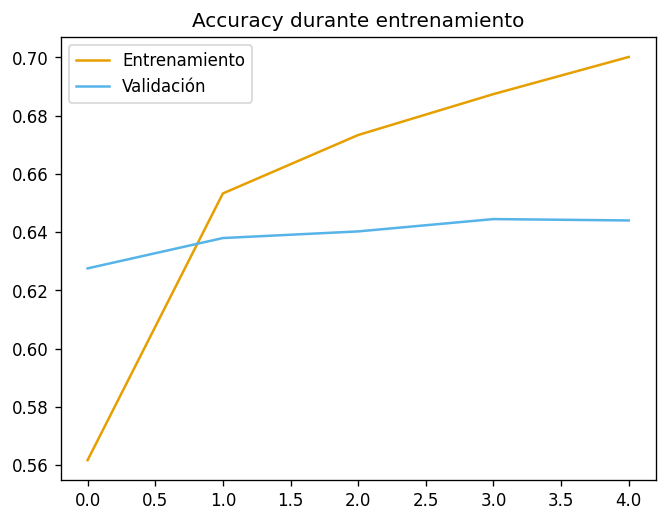

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy en test: {acc:.3f}")

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy durante entrenamiento')
plt.legend()
plt.show()

# 7 - Modelo LSTM Mejorado con mas capas

In [ ]:
model_deep = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_deep.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_deep = model_deep.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,  # Más épocas para ver evolución
    batch_size=128
)


Epoch 1/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - accuracy: 0.4298 - loss: 1.3077 - val_accuracy: 0.6336 - val_loss: 0.9357
Epoch 2/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 149s 93ms/step - accuracy: 0.6538 - loss: 0.8912 - val_accuracy: 0.6433 - val_loss: 0.9073
Epoch 3/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 180s 78ms/step - accuracy: 0.6793 - loss: 0.8184 - val_accuracy: 0.6475 - val_loss: 0.9013
Epoch 4/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 120s 78ms/step - accuracy: 0.6953 - loss: 0.7745 - val_accuracy: 0.6463 - val_loss: 0.9105
Epoch 5/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 130s 84ms/step - accuracy: 0.7088 - loss: 0.7391 - val_accuracy: 0.6457 - val_loss: 0.9193
Epoch 6/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 132s 78ms/step - accuracy: 0.7234 - loss: 0.6969 - val_accuracy: 0.6463 - val_loss: 0.9427
Epoch 7/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 121s 79ms/step - accuracy: 0.7412 - loss: 0.6539 - val_accuracy: 0.6432 - val_loss: 0.9837
Epoch 8/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 142s 79ms/step - accuracy: 

# 8 - Modelo LSTM Mejorado con mas neuronas

In [ ]:
from tensorflow.keras.layers import Dropout

model_wide = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),  # Más dimensión
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_wide.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_wide.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_wide = model_wide.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=128
)

Epoch 1/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 290s 186ms/step - accuracy: 0.4616 - loss: 1.2702 - val_accuracy: 0.6276 - val_loss: 0.9423
Epoch 2/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 305s 175ms/step - accuracy: 0.6535 - loss: 0.9002 - val_accuracy: 0.6388 - val_loss: 0.9132
Epoch 3/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 286s 186ms/step - accuracy: 0.6778 - loss: 0.8281 - val_accuracy: 0.6460 - val_loss: 0.9004
Epoch 4/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 302s 173ms/step - accuracy: 0.7005 - loss: 0.7720 - val_accuracy: 0.6485 - val_loss: 0.9090
Epoch 5/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 347s 190ms/step - accuracy: 0.7179 - loss: 0.7210 - val_accuracy: 0.6467 - val_loss: 0.9271
Epoch 6/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 318s 187ms/step - accuracy: 0.7376 - loss: 0.6702 - val_accuracy: 0.6453 - val_loss: 0.9712
Epoch 7/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 321s 187ms/step - accuracy: 0.7604 - loss: 0.6114 - val_accuracy: 0.6431 - val_loss: 1.0201
Epoch 8/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 300s 173ms/step - accuracy: 

In [ ]:
def plot_history(hist, title=''):
    plt.figure(figsize=(7,5))
    plt.plot(hist.history['accuracy'], label='Entrenamiento')
    plt.plot(hist.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(hist.history['loss'], label='Entrenamiento')
    plt.plot(hist.history['val_loss'], label='Validación')
    plt.title(f'Loss {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

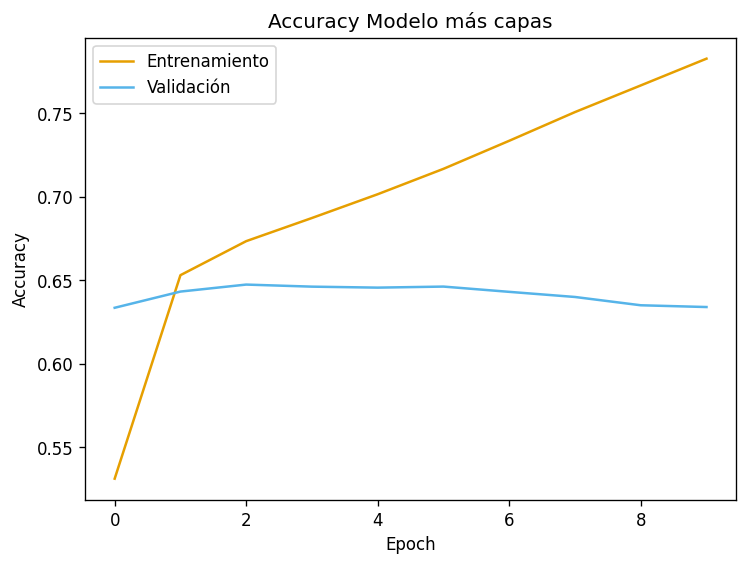

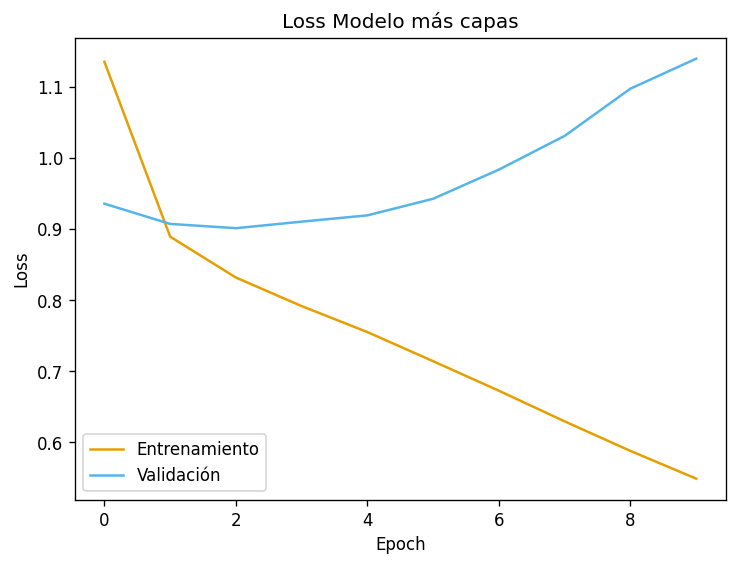

In [ ]:
# Graficá cada modelo
plot_history(history_deep, 'Modelo más capas')

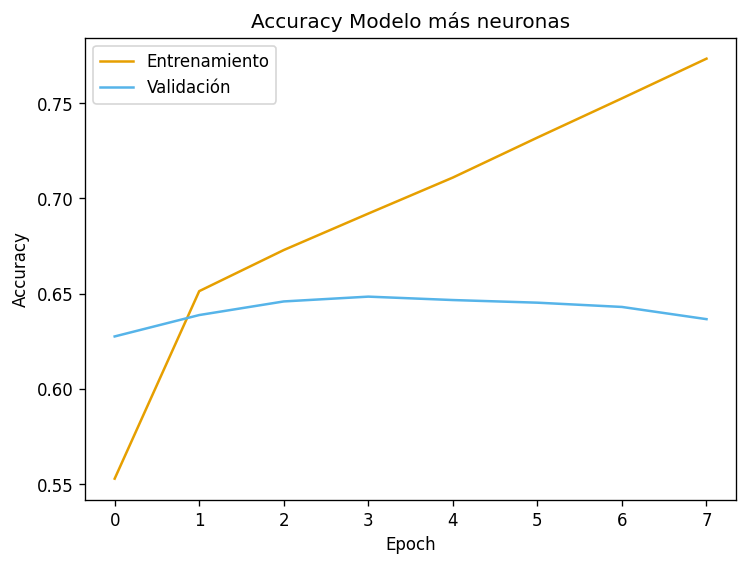

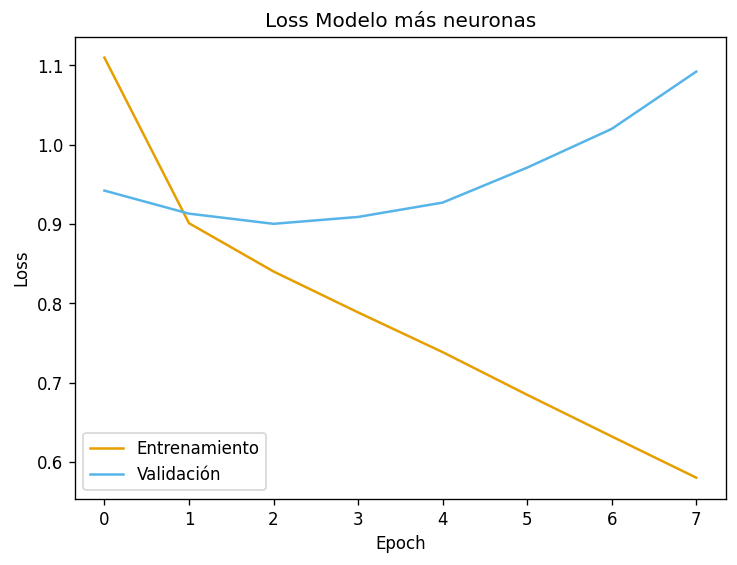

In [ ]:
plot_history(history_wide, 'Modelo más neuronas')

In [ ]:
# Accuracy final en test para cada modelo
loss_deep, acc_deep = model_deep.evaluate(X_test, y_test, verbose=0)
loss_wide, acc_wide = model_wide.evaluate(X_test, y_test, verbose=0)

print(f"Modelo más capas - Accuracy test: {acc_deep:.3f} | Loss: {loss_deep:.3f}")
print(f"Modelo más neuronas - Accuracy test: {acc_wide:.3f} | Loss: {loss_wide:.3f}")


Modelo más capas - Accuracy test: 0.634 | Loss: 1.140
Modelo más neuronas - Accuracy test: 0.637 | Loss: 1.092


# 9 - Modelo LSTM con Dropout

In [ ]:
model_dropout = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),
    LSTM(64, return_sequences=True),
    Dropout(0.3),  # Dropout después del primer LSTM
    LSTM(32),
    Dropout(0.3),  # Dropout después del segundo LSTM
    Dense(32, activation='relu'),
    Dropout(0.3),  # Dropout antes de la capa de salida
    Dense(num_classes, activation='softmax')
])

model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dropout.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=128
)

Epoch 1/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 134s 84ms/step - accuracy: 0.4002 - loss: 1.3633 - val_accuracy: 0.6222 - val_loss: 0.9670
Epoch 2/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 129s 84ms/step - accuracy: 0.6384 - loss: 0.9508 - val_accuracy: 0.6392 - val_loss: 0.9175
Epoch 3/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 141s 83ms/step - accuracy: 0.6663 - loss: 0.8757 - val_accuracy: 0.6438 - val_loss: 0.9158
Epoch 4/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 128s 83ms/step - accuracy: 0.6792 - loss: 0.8413 - val_accuracy: 0.6437 - val_loss: 0.9205
Epoch 5/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 152s 90ms/step - accuracy: 0.6930 - loss: 0.7969 - val_accuracy: 0.6400 - val_loss: 0.9405
Epoch 6/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 143s 90ms/step - accuracy: 0.7071 - loss: 0.7619 - val_accuracy: 0.6449 - val_loss: 0.9511
Epoch 7/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 138s 90ms/step - accuracy: 0.7249 - loss: 0.7223 - val_accuracy: 0.6437 - val_loss: 0.9832
Epoch 8/8
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 142s 90ms/step - accuracy: 0.7372 -

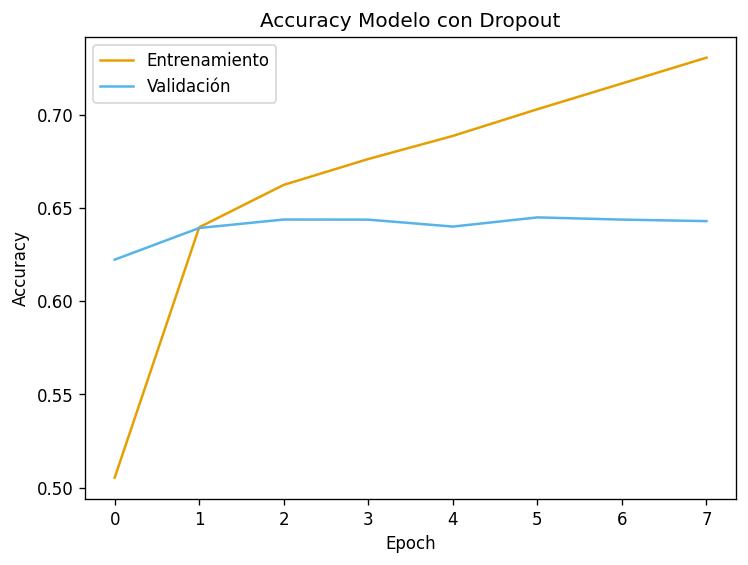

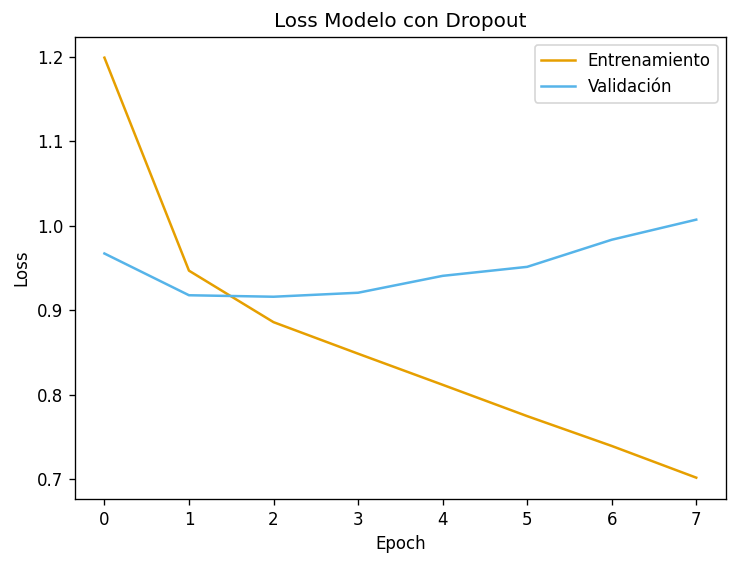

In [ ]:
plot_history(history_dropout, 'Modelo con Dropout')

In [ ]:
#Evaluación final
loss_drop, acc_drop = model_dropout.evaluate(X_test, y_test, verbose=0)
print(f"Modelo con Dropout - Accuracy test: {acc_drop:.3f} | Loss: {loss_drop:.3f}")

Modelo con Dropout - Accuracy test: 0.643 | Loss: 1.007


# 10 - Modelo CNN

In [ ]:
print("Clases detectadas:", num_classes, np.unique(y))

Clases detectadas: 5 [0 1 2 3 4]


In [ ]:
# Vector de clases (0, 1, 2, 3, 4)
num_classes = 5
y_cat = to_categorical(y, num_classes=num_classes)

# Split train/val/test
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
max_words = 10000
maxlen = 30
embedding_dim = 64

cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=maxlen),
    Conv1D(64, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')   # 5 clases de salida
])

cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_data=(X_val, y_val)
)

score_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Modelo CNN 5 clases - Accuracy test: {score_cnn[1]:.3f} | Loss: {score_cnn[0]:.3f}")

Epoch 1/5
769/769 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.4059 - loss: 1.3708 - val_accuracy: 0.6302 - val_loss: 0.9488
Epoch 2/5
769/769 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.6429 - loss: 0.9357 - val_accuracy: 0.6423 - val_loss: 0.9209
Epoch 3/5
769/769 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.6735 - loss: 0.8562 - val_accuracy: 0.6429 - val_loss: 0.9161
Epoch 4/5
769/769 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.6996 - loss: 0.7889 - val_accuracy: 0.6427 - val_loss: 0.9305
Epoch 5/5
769/769 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.7227 - loss: 0.7337 - val_accuracy: 0.6382 - val_loss: 0.9551
Modelo CNN 5 clases - Accuracy test: 0.643 | Loss: 0.946


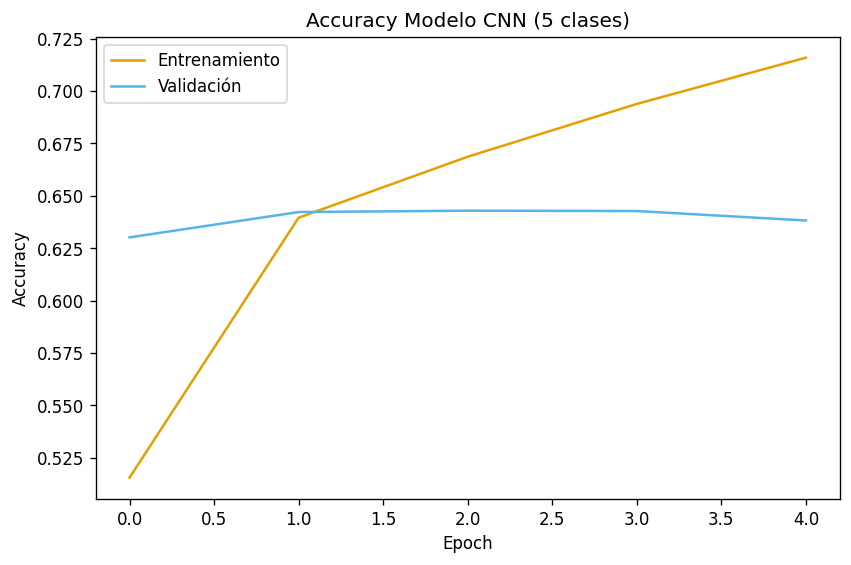

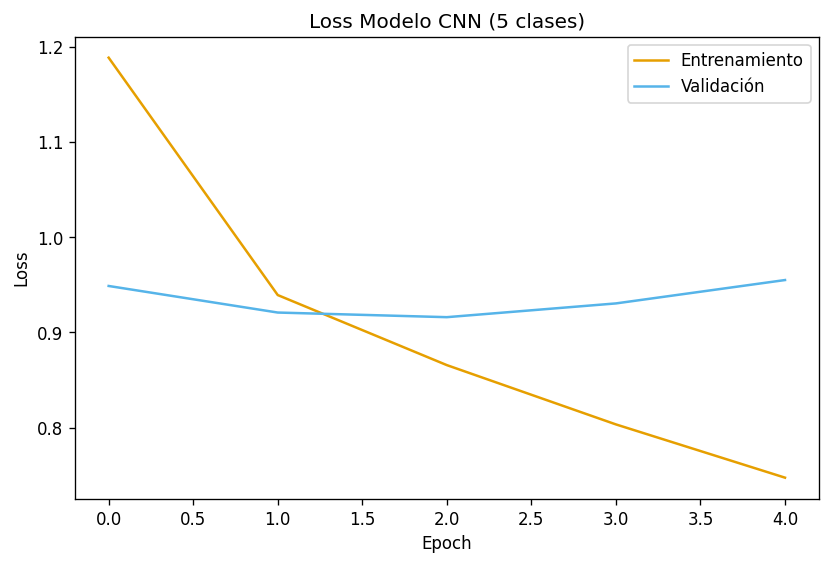

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Entrenamiento')
plt.plot(history_cnn.history['val_accuracy'], label='Validación')
plt.title("Accuracy Modelo CNN (5 clases)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Entrenamiento')
plt.plot(history_cnn.history['val_loss'], label='Validación')
plt.title("Loss Modelo CNN (5 clases)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 11 - Modelo MLP + TF-IDF (Keras):

In [ ]:
# Convertí los lemas a strings
df['lemmas_str'] = df['lemmas'].apply(lambda x: ' '.join(x))

# TF-IDF vectorización
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['lemmas_str']).toarray()

In [ ]:
# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_cat, test_size=0.2, random_state=42)

In [ ]:
# MLP con Keras
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,709 (534.02 KB)

 Trainable params: 136,709 (534.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)

Epoch 1/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.4319 - loss: 1.3429 - val_accuracy: 0.5435 - val_loss: 1.1307
Epoch 2/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5400 - loss: 1.1435 - val_accuracy: 0.5523 - val_loss: 1.1096
Epoch 3/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5561 - loss: 1.1090 - val_accuracy: 0.5574 - val_loss: 1.0987
Epoch 4/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.5671 - loss: 1.0846 - val_accuracy: 0.5596 - val_loss: 1.0889
Epoch 5/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5768 - loss: 1.0635 - val_accuracy: 0.5643 - val_loss: 1.0793
Epoch 6/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5897 - loss: 1.0382 - val_accuracy: 0.5669 - val_loss: 1.0746
Epoch 7/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.5973 - loss: 1.0221 - val_accuracy: 0.5694 - val_loss: 1.0715
Epoch 8/10
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6039 - loss: 1

In [ ]:
# Evaluación
score_mlp = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"Modelo MLP - Accuracy test: {score_mlp[1]:.3f} | Loss: {score_mlp[0]:.3f}")

Modelo MLP - Accuracy test: 0.569 | Loss: 1.075


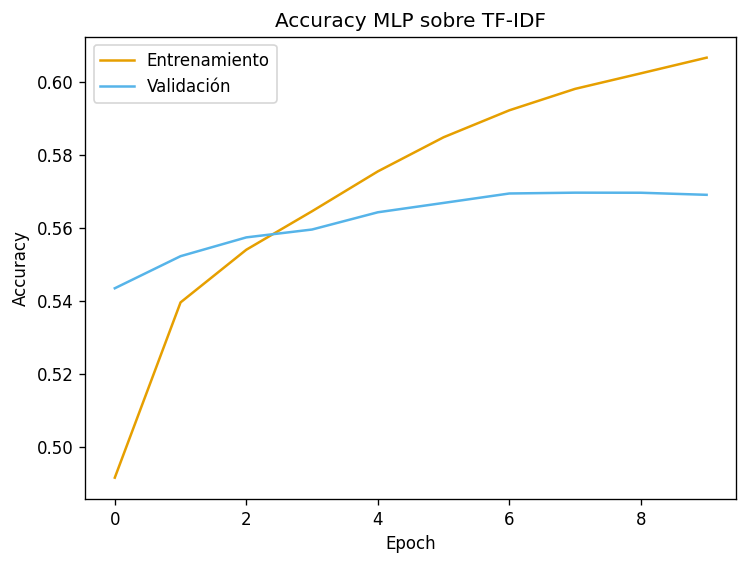

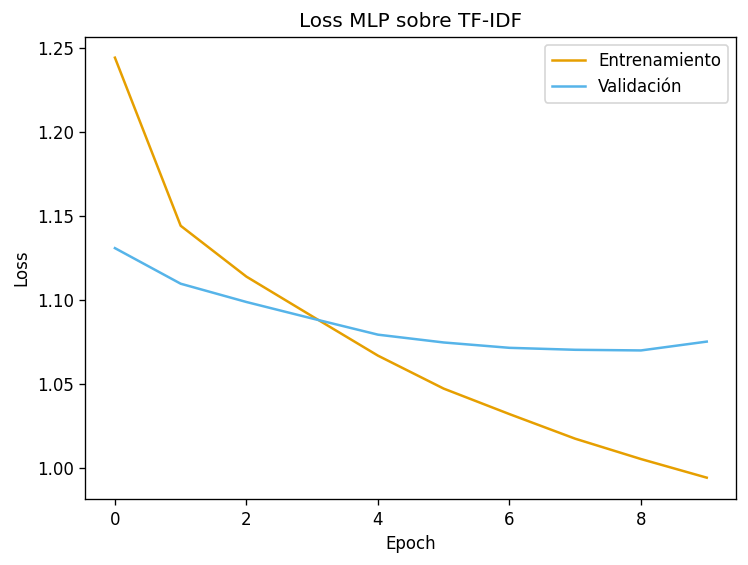

In [ ]:
plot_history(history_mlp, 'MLP sobre TF-IDF')

# 12 - Cross-Validation con LSTM

In [ ]:
# Convertimos y a categorical one-hot:
y_cat = to_categorical(y, num_classes=5)

# Definimos el KFold
k = 3  # Usá 3 o 5 según tu RAM
kf = KFold(n_splits=k, shuffle=True, random_state=42)

val_accuracies = []
val_losses = []

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"\n=== Fold {fold+1}/{k} ===")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y_cat[train_index], y_cat[val_index]


=== Fold 1/3 ===

=== Fold 2/3 ===

=== Fold 3/3 ===


In [ ]:
  # Modelo LSTM
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),
        LSTM(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=5, batch_size=128, verbose=2)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)
    print(f"Fold {fold+1} - Val Accuracy: {val_acc:.3f} | Val Loss: {val_loss:.3f}")



Epoch 1/5
1281/1281 - 80s - 62ms/step - accuracy: 0.5290 - loss: 1.1497 - val_accuracy: 0.6052 - val_loss: 0.9917
Epoch 2/5
1281/1281 - 76s - 60ms/step - accuracy: 0.6483 - loss: 0.9002 - val_accuracy: 0.6397 - val_loss: 0.9307
Epoch 3/5
1281/1281 - 77s - 60ms/step - accuracy: 0.6745 - loss: 0.8334 - val_accuracy: 0.6397 - val_loss: 0.9297
Epoch 4/5
1281/1281 - 85s - 66ms/step - accuracy: 0.6871 - loss: 0.7944 - val_accuracy: 0.6363 - val_loss: 0.9435
Epoch 5/5
1281/1281 - 133s - 104ms/step - accuracy: 0.7006 - loss: 0.7584 - val_accuracy: 0.6393 - val_loss: 0.9538
Fold 3 - Val Accuracy: 0.639 | Val Loss: 0.954


In [ ]:
print("\n--- Resultados Cross-Validation ---")
print("Accuracies:", np.round(val_accuracies, 3))
print("Promedio accuracy:", np.mean(val_accuracies).round(3))
print("Promedio loss:", np.mean(val_losses).round(3))


--- Resultados Cross-Validation ---
Accuracies: [0.639]
Promedio accuracy: 0.639
Promedio loss: 0.954
